interactive(children=(FloatSlider(value=0.0, description='a', max=1.0, min=-1.0), Checkbox(value=False, descri…

-1.0
-0.9
-0.8
-0.7
-0.6
-0.5
-0.4
-0.3
-0.2
-0.1
0.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9


C:\Users\Vu Phan\AppData\Local\Temp\ipykernel_19108\658097385.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


1.0


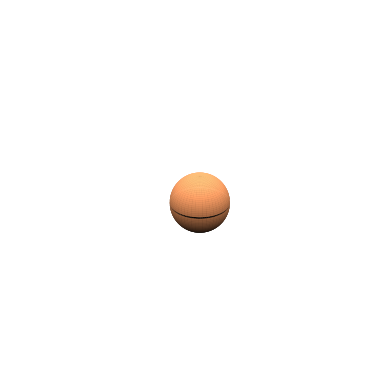

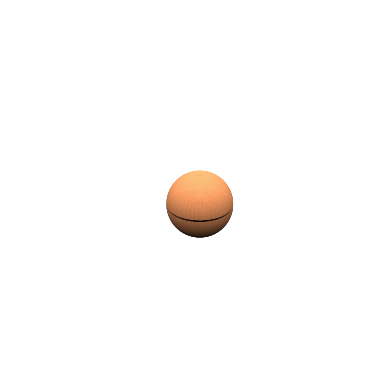

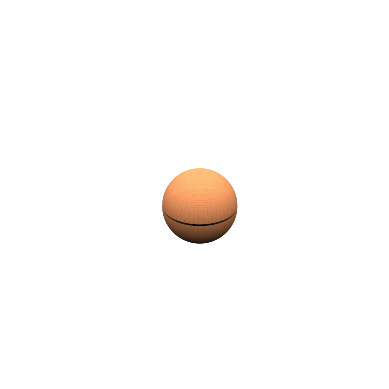

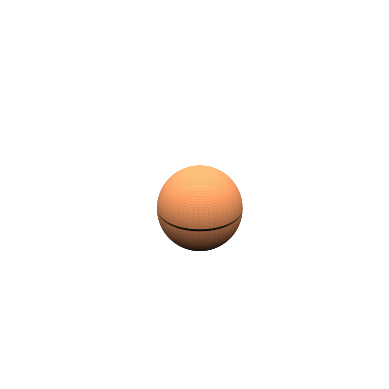

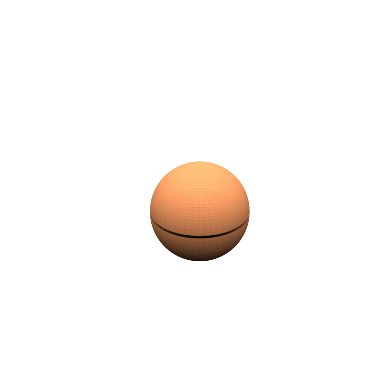

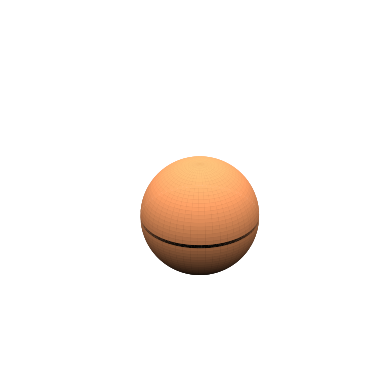

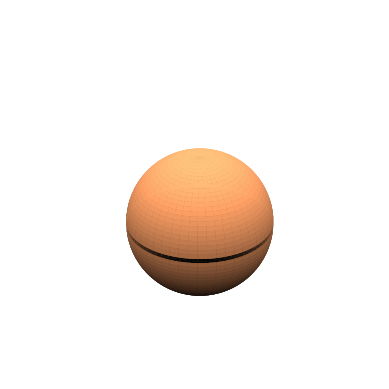

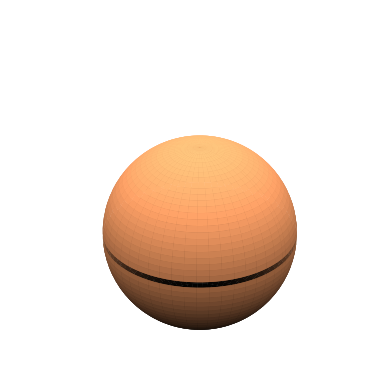

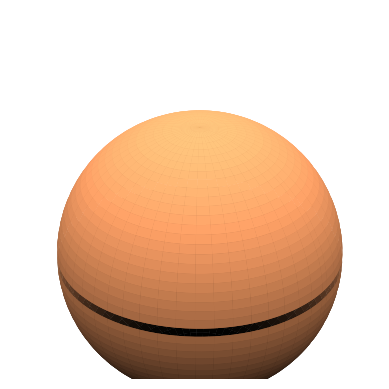

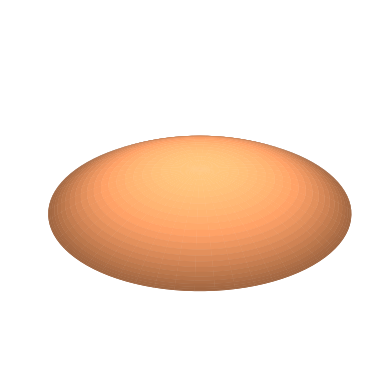

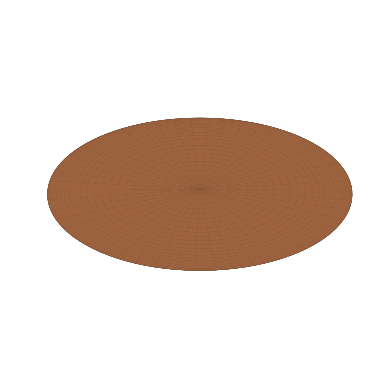

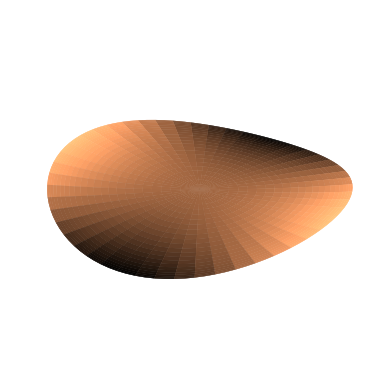

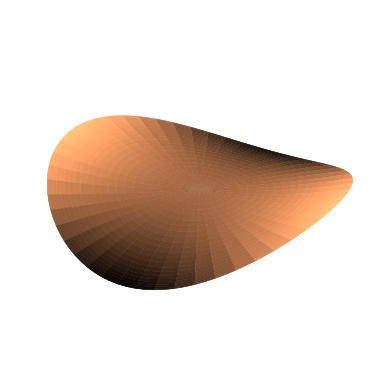

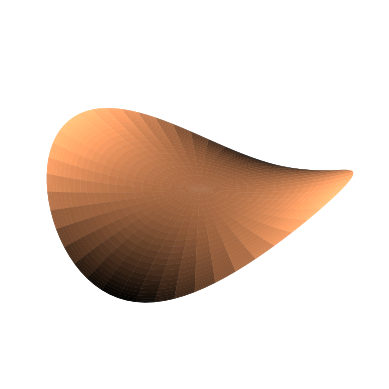

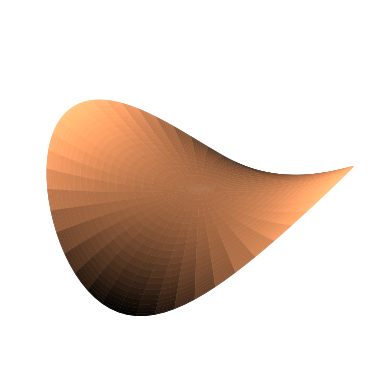

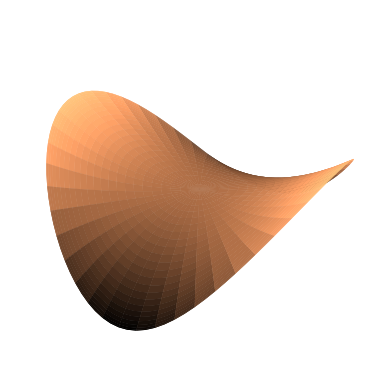

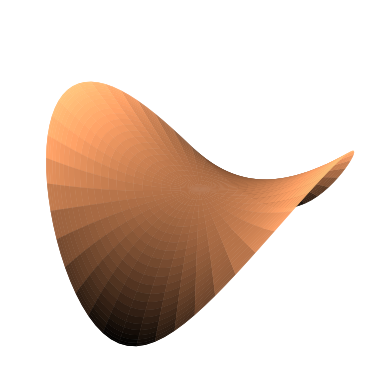

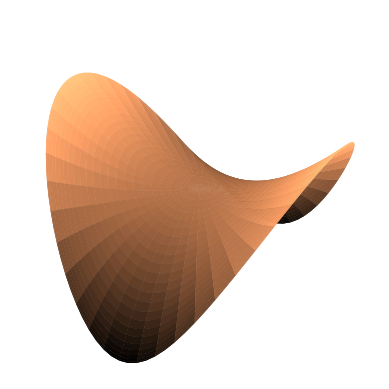

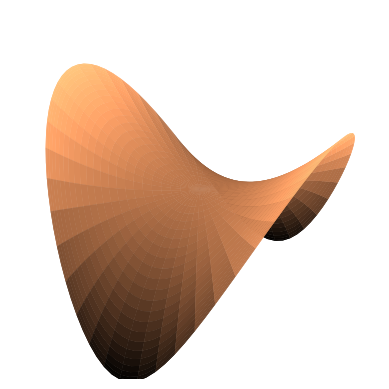

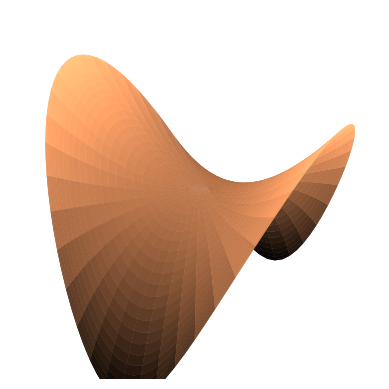

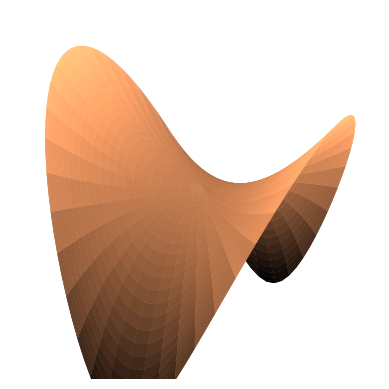

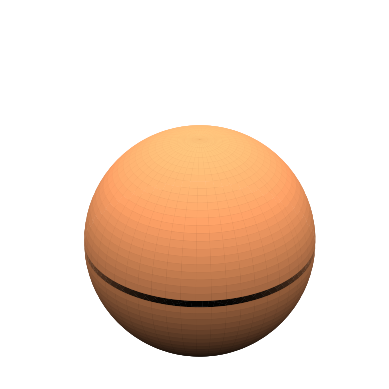

In [47]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from ipywidgets import interact

import matplotlib.pyplot as plt

# Define the function to plot the surface
def plot_surface(a,save=False):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Generate the data
    phi = np.linspace(0, 2 * np.pi, 100)
    theta = np.linspace(0, np.pi, 50)
    phi, theta = np.meshgrid(phi, theta)
    
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    if a > 0:
        z = (np.sqrt(1.1**2 + a * x**2 - a * y**2) - 1.1)*2
    if a == 0:
        z = np.full_like(x, 0)
    if a < 0:
        radius = 0.2/(np.abs(a)+0.01)
        if radius < 1:    
            x = radius*np.sin(theta) * np.cos(phi)
            y = radius*np.sin(theta) * np.sin(phi)
        z = np.sqrt(radius**2 - x**2 - y**2) - radius
        z_center = 0.5*(np.min(z) + np.max(z))
        z = z - z_center
        inv_z = -np.sqrt(radius**2 - x**2 - y**2) - radius
        inv_z = inv_z - z_center
    # z = np.sqrt(1/(np.abs(a)+0.1) + a * x**2 - np.abs(a) * y**2)
    
    ax.set_zlim(-0.75,0.75)
    # Plot the surface
    if a >= 0:
        ax.plot_surface(x, y, z, cmap='copper')
    if a == 0:
        ax.plot_surface(x, y, z, cmap='copper',vmin=-1,vmax=1)
    if a < 0:
        radius = 0.2/(np.abs(a)+0.01)
        zmax = np.max(z)
        zmin = 2*np.min(z) - zmax
        ax.plot_surface(x, y, z, cmap='copper',vmin=zmin,vmax=zmax)
        if radius < 1:
            ax.plot_surface(x, y, inv_z, cmap='copper',vmin=zmin,vmax=zmax)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    ax.set_xlim(-0.75,0.75)
    ax.set_ylim(-0.75,0.75)
    ax.set_aspect('equal')
    
    ax.set_axis_off()
    if save:
        plt.savefig('../Simulator/media/img/curvature/curvature'+str(a)+'.png', dpi=300,transparent=True, bbox_inches='tight', pad_inches=0)
    else:
        plt.show()

# Create the interactive slider
interact(plot_surface, a=widgets.FloatSlider(min=-1, max=1, step=0.1, value=0))

for a in np.linspace(-1,1,21):
    plot_surface(round(a,1),save=True)
    print(round(a,1))
plot_surface(-0.25,save=True)